# Complementaria Semana 6: Simulación de un Proceso de Poisson

Llevas dos semanas escribiendo esta línea sin detenerte a pensar qué es:

```python
yield env.timeout(random.expovariate(lam))
```

Ese generador de llegadas que usaste para la cola M/M/1 **es un proceso de Poisson**. Hoy le ponemos nombre, estudiamos sus propiedades y verificamos —simulando— que efectivamente se comporta como dice la teoría.

### Objetivo de hoy

Al final de la sesión deberías poder mirar un flujo de eventos en el tiempo (llegadas de clientes, llamadas, fallas) y saber **qué te permite afirmar el modelo de Poisson y cómo comprobarlo con datos**.

| Bloque | Tema |
|---|---|
| 1 | Qué es un proceso de Poisson y cómo se simula |
| 2 | Verificación 1: los tiempos entre eventos son Exponenciales |
| 3 | Verificación 2: $N(T)$ es Poisson, y dos formas de simular lo mismo |
| 4 | Superposición: qué pasa al juntar dos procesos |
| 5 | División (*thinning*): qué pasa al separar uno |
| 6 | El puente: tu generador de SimPy es un proceso de Poisson |
| 7 | Ejercicio aplicado |


## 0. Preparación

Este notebook se trabaja en **VS Code**, sobre el ambiente virtual de los tutoriales de la semana 1. Si te falta alguna librería, descomenta la primera línea.

In [ ]:
# %pip install numpy matplotlib scipy simpy

import numpy as np
import matplotlib.pyplot as plt
import random
import simpy
from scipy import stats

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Note: you may need to restart the kernel to use updated packages.


## 1. ¿Qué es un proceso de Poisson?

Un **proceso de Poisson** con tasa $\lambda > 0$ es un modelo para eventos que ocurren de forma aleatoria en el tiempo. Se denota $N(t)$ y cuenta **cuántos eventos han ocurrido hasta el instante $t$**.

Sirve para modelar llegadas de clientes a una fila, llamadas a un call center, fallas de una máquina, mensajes a un servidor: situaciones donde los eventos ocurren de a uno, de forma independiente, y a un ritmo promedio constante.

### La definición que usaremos para simular

La caracterización más útil en simulación es esta: **los tiempos entre eventos son exponenciales independientes**.

$$
T_i \overset{iid}{\sim} \text{Exp}(\lambda)
\qquad\qquad
S_n = \sum_{i=1}^{n} T_i
$$

donde $T_i$ es el tiempo que pasa entre el evento $i-1$ y el $i$, y $S_n$ es el instante en que ocurre el evento $n$.

De ahí sale el algoritmo directamente:

1. Generar $T_i \sim \text{Exp}(\lambda)$.
2. Acumular: $S_n = T_1 + \cdots + T_n$.
3. Parar cuando $S_n$ supere el horizonte $T$.

$\lambda$ se interpreta como **eventos por unidad de tiempo**, y $1/\lambda$ como el **tiempo promedio entre eventos**.

In [2]:
def simular_proceso_poisson(lam, T, rng):
    # Simula un proceso de Poisson de tasa 'lam' en el intervalo [0, T).
    # Devuelve los INSTANTES en que ocurren los eventos.
    tiempos = []
    t = 0.0
    while True:
        t += rng.exponential(scale=1/lam)   # tiempo hasta el siguiente evento ~ Exp(lam)
        if t > T:                           # nos pasamos del horizonte: paramos
            break
        tiempos.append(t)
    return np.array(tiempos)


rng = np.random.default_rng(0)

lam = 2.0   # eventos por unidad de tiempo
T   = 10.0  # horizonte

llegadas = simular_proceso_poisson(lam, T, rng)

print(f"Instantes de los eventos: {np.round(llegadas, 3)}")
print(f"\nN(T) = {len(llegadas)} eventos   (esperado: lambda*T = {lam*T:.0f})")

Instantes de los eventos: [0.34  0.85  0.86  0.861 1.136 1.951 2.288 2.665 4.074 7.103 8.746 8.747
 9.881 9.917]

N(T) = 14 eventos   (esperado: lambda*T = 20)


### La trayectoria de $N(t)$

$N(t)$ es una **función escalonada**: vale 0 hasta el primer evento y sube un escalón cada vez que ocurre uno. Es exactamente el mismo tipo de curva que $N(t)$ en la complementaria pasada, cuando contábamos clientes en el sistema, solo que aquí nunca baja.

Grafiquemos **varias trayectorias** en lugar de una, para ver algo importante: todas tienen la misma tasa $\lambda$, pero ninguna se parece a otra.

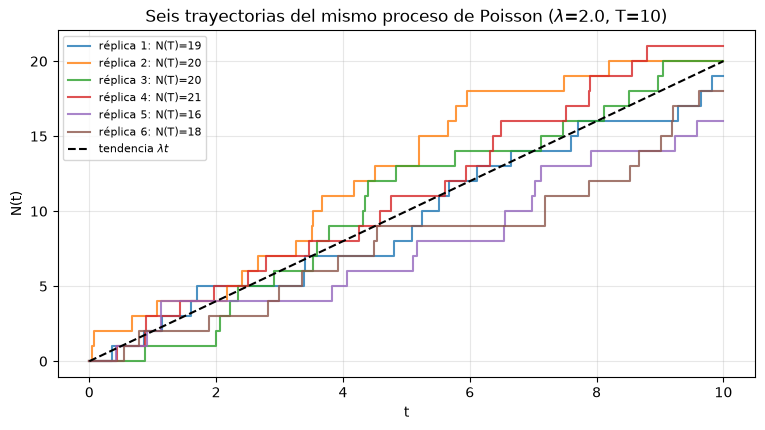

In [3]:
plt.figure(figsize=(9, 4.5))

rng_traj = np.random.default_rng(7)
for r in range(6):
    ll = simular_proceso_poisson(lam, T, rng_traj)
    tiempos = np.concatenate(([0.0], ll, [T]))
    conteo  = np.concatenate(([0], np.arange(1, len(ll)+1), [len(ll)]))
    plt.step(tiempos, conteo, where="post", alpha=0.8, label=f"réplica {r+1}: N(T)={len(ll)}")

plt.plot([0, T], [0, lam*T], "k--", linewidth=1.5, label=r"tendencia $\lambda t$")
plt.title(f"Seis trayectorias del mismo proceso de Poisson ($\\lambda$={lam}, T={T:.0f})")
plt.xlabel("t"); plt.ylabel("N(t)")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.show()

Las seis curvas siguen en promedio la recta $\lambda t$, pero el número final de eventos varía bastante entre réplicas. **Esa dispersión no es ruido a eliminar: es el fenómeno.** Es la misma razón por la que en la semana 5 necesitábamos réplicas para estimar $W_q$.

## 2. Verificación 1: los tiempos entre eventos son $\text{Exp}(\lambda)$

Lo construimos así por definición, pero verifiquémoslo como si nos hubieran entregado los datos sin decirnos de dónde salen. Tres comprobaciones:

- histograma contra la pdf teórica,
- media y varianza empíricas contra las teóricas ($1/\lambda$ y $1/\lambda^2$),
- **test de Kolmogorov–Smirnov**, que compara la CDF empírica con la teórica.

Eventos simulados: 59,986
Media  : 0.33341   teórica: 0.33333
Varianza: 0.11217   teórica: 0.11111

KS: estadístico = 0.00394, p-valor = 0.3081
El p-valor alto significa que NO hay evidencia para rechazar que sean Exp(lambda).


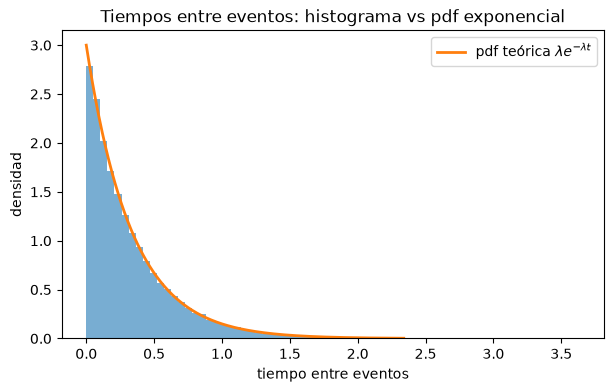

In [4]:
lam_v = 3.0
T_largo = 20_000.0

llegadas_largo = simular_proceso_poisson(lam_v, T_largo, rng)
interarribos   = np.diff(np.concatenate(([0.0], llegadas_largo)))

print(f"Eventos simulados: {len(llegadas_largo):,}")
print(f"Media  : {interarribos.mean():.5f}   teórica: {1/lam_v:.5f}")
print(f"Varianza: {interarribos.var(ddof=1):.5f}   teórica: {1/lam_v**2:.5f}")

D, pvalor = stats.kstest(interarribos, "expon", args=(0, 1/lam_v))   # scale = 1/lambda
print(f"\nKS: estadístico = {D:.5f}, p-valor = {pvalor:.4f}")
print("El p-valor alto significa que NO hay evidencia para rechazar que sean Exp(lambda).")

plt.figure(figsize=(7, 4))
plt.hist(interarribos, bins=70, density=True, alpha=0.6)
malla = np.linspace(0, np.quantile(interarribos, 0.999), 400)
plt.plot(malla, lam_v*np.exp(-lam_v*malla), linewidth=2, label=r"pdf teórica $\lambda e^{-\lambda t}$")
plt.title("Tiempos entre eventos: histograma vs pdf exponencial")
plt.xlabel("tiempo entre eventos"); plt.ylabel("densidad")
plt.legend(); plt.show()

## 3. Verificación 2: $N(T) \sim \text{Poisson}(\lambda T)$

La otra cara del proceso. Si los tiempos entre eventos son $\text{Exp}(\lambda)$, entonces el **número de eventos** en un horizonte $T$ sigue una distribución de Poisson:

$$
N(T) \sim \text{Poisson}(\lambda T)
\qquad\text{con}\qquad
\mathbb{E}[N(T)] = \mathrm{Var}(N(T)) = \lambda T
$$

Fíjate en esa igualdad entre media y varianza: es una firma característica de la Poisson y una de las primeras cosas que se revisan cuando uno quiere saber si un conteo real se puede modelar así.

Para verificarlo repetimos la simulación muchas veces y guardamos cuántos eventos hubo en cada réplica.

E[N(T)]   empírica: 14.9968   teórica: 15.0000
Var[N(T)] empírica: 15.1692   teórica: 15.0000


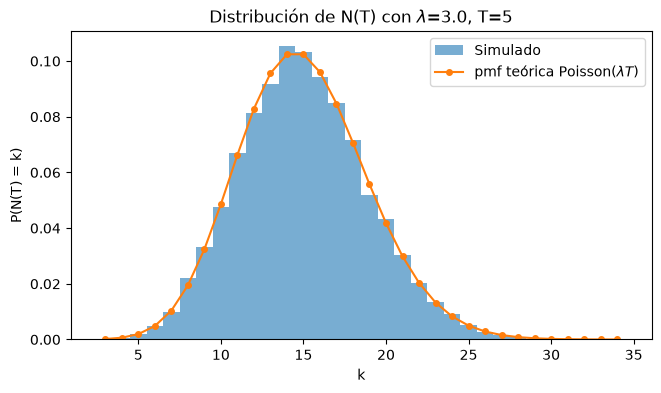

In [5]:
lam_n, T_n, R = 3.0, 5.0, 20_000

# Método 1: simular las llegadas una por una y contarlas
NT = np.array([len(simular_proceso_poisson(lam_n, T_n, rng)) for _ in range(R)])

print(f"E[N(T)]   empírica: {NT.mean():.4f}   teórica: {lam_n*T_n:.4f}")
print(f"Var[N(T)] empírica: {NT.var(ddof=1):.4f}   teórica: {lam_n*T_n:.4f}")

# Comparación de la distribución completa contra la pmf teórica
valores = np.arange(NT.min(), NT.max()+1)
pmf_teo = stats.poisson.pmf(valores, mu=lam_n*T_n)

plt.figure(figsize=(7.5, 4))
plt.hist(NT, bins=np.arange(NT.min(), NT.max()+2)-0.5, density=True, alpha=0.6, label="Simulado")
plt.plot(valores, pmf_teo, "o-", linewidth=1.5, markersize=4, label=r"pmf teórica Poisson($\lambda T$)")
plt.title(f"Distribución de N(T) con $\\lambda$={lam_n}, T={T_n:.0f}")
plt.xlabel("k"); plt.ylabel("P(N(T) = k)")
plt.legend(); plt.show()

### Dos formas de simular exactamente el mismo proceso

Acabamos de simular generando los tiempos entre eventos uno por uno. Pero hay una segunda forma, y es **mucho más rápida**:

1. Sortear cuántos eventos habrá: $N(T) \sim \text{Poisson}(\lambda T)$.
2. Repartir esos $N(T)$ eventos **uniformemente al azar** dentro de $[0, T]$ y ordenarlos.

Que esto funcione no es obvio, y es un resultado interesante: **dado que ocurrieron $n$ eventos en $[0,T]$, sus instantes se distribuyen como $n$ uniformes ordenadas.** Un proceso de Poisson no tiene preferencia por ningún momento del intervalo.

Comprobemos que las dos formas producen lo mismo:

In [6]:
def simular_poisson_uniformes(lam, T, rng):
    # Método 2: primero cuántos, después dónde
    n = rng.poisson(lam*T)
    return np.sort(rng.uniform(0, T, size=n))


# Comparamos la distribución de N(T) por ambos métodos
NT_metodo2 = rng.poisson(lam_n*T_n, size=R)

print(f"Método 1 (interarribos): E = {NT.mean():.4f}   Var = {NT.var(ddof=1):.4f}")
print(f"Método 2 (uniformes)   : E = {NT_metodo2.mean():.4f}   Var = {NT_metodo2.var(ddof=1):.4f}")

ks = stats.ks_2samp(NT, NT_metodo2)
print(f"\nKS de dos muestras entre ambos métodos: p-valor = {ks.pvalue:.4f}")
print("No se distinguen: son el mismo proceso.")

# Y los tiempos del método 2 también dan interarribos exponenciales
tiempos_m2 = simular_poisson_uniformes(lam_v, T_largo, rng)
p2 = stats.kstest(np.diff(tiempos_m2), "expon", args=(0, 1/lam_v)).pvalue
print(f"KS de los interarribos del método 2 vs Exp(lambda): p-valor = {p2:.4f}")

Método 1 (interarribos): E = 14.9968   Var = 15.1692
Método 2 (uniformes)   : E = 14.9650   Var = 14.8597

KS de dos muestras entre ambos métodos: p-valor = 0.6581
No se distinguen: son el mismo proceso.
KS de los interarribos del método 2 vs Exp(lambda): p-valor = 0.7463


> **Cuándo usar cada uno:** Si solo te interesa *cuántos* eventos hubo, el método 2 es inmediato y evita el bucle. Si necesitas los **instantes** para alimentar una simulación —como el generador de llegadas de SimPy, que va entregando clientes a medida que el reloj avanza— el método 1 es el natural, porque produce los eventos en orden y sobre la marcha.

## 4. Superposición: juntar dos procesos

Si $N_1(t)$ y $N_2(t)$ son procesos de Poisson **independientes** con tasas $\lambda_1$ y $\lambda_2$, entonces el proceso que resulta de juntar todos sus eventos es un proceso de Poisson con tasa

$$
\lambda = \lambda_1 + \lambda_2
$$

Es lo que pasa cuando dos flujos de clientes llegan a la misma fila, o cuando dos tipos de falla alimentan el mismo registro de mantenimiento.

Lo que hay que verificar ahora es que **el proceso fusionado sea un proceso de Poisson**, y para eso hay que mezclar los **instantes** de los eventos y mirar los tiempos entre ellos.

In [7]:
lam1, lam2 = 2.0, 5.0
T_sup = 20_000.0

eventos_1 = simular_proceso_poisson(lam1, T_sup, rng)
eventos_2 = simular_proceso_poisson(lam2, T_sup, rng)

# Fusionamos los INSTANTES de ambos procesos y los ordenamos
fusionado = np.sort(np.concatenate([eventos_1, eventos_2]))
inter_fus = np.diff(fusionado)

print(f"Eventos del proceso 1: {len(eventos_1):,}")
print(f"Eventos del proceso 2: {len(eventos_2):,}")
print(f"Eventos fusionados   : {len(fusionado):,}   (esperado: {(lam1+lam2)*T_sup:,.0f})")

print(f"\nMedia de los interarribos fusionados: {inter_fus.mean():.5f}")
print(f"Teórica 1/(lambda1+lambda2)         : {1/(lam1+lam2):.5f}")

p_sup = stats.kstest(inter_fus, "expon", args=(0, 1/(lam1+lam2))).pvalue
print(f"\nKS de los interarribos fusionados vs Exp(lambda1+lambda2): p-valor = {p_sup:.4f}")

Eventos del proceso 1: 40,197
Eventos del proceso 2: 99,930
Eventos fusionados   : 140,127   (esperado: 140,000)

Media de los interarribos fusionados: 0.14273
Teórica 1/(lambda1+lambda2)         : 0.14286

KS de los interarribos fusionados vs Exp(lambda1+lambda2): p-valor = 0.8671


El p-valor alto confirma lo que importa: al juntar los dos flujos resulta otra vez un proceso de Poisson, ahora con tasa $\lambda_1 + \lambda_2 = 7$. Por eso en un modelo de colas puedes sumar todas las fuentes de llegada en un único $\lambda$ y seguir usando las fórmulas de la M/M/1.

## 5. División (*thinning*): separar un proceso

La operación inversa. Si $N(t)$ es Poisson con tasa $\lambda$ y cada evento se clasifica de forma independiente como **tipo A** con probabilidad $p$ y **tipo B** con probabilidad $1-p$, entonces:

$$
N_A(t) \sim \text{Poisson}(p\lambda t)
\qquad\qquad
N_B(t) \sim \text{Poisson}((1-p)\lambda t)
$$

Es el caso de un call center donde las llamadas se separan en soporte y ventas, o de una línea de producción donde las piezas se clasifican en conformes y no conformes.

Hasta aquí es lo esperado. Lo que **no** es esperado es esto:

> **$N_A$ y $N_B$ son independientes entre sí.**

Piénsalo un segundo antes de seguir. Los dos salen del mismo proceso y además cumplen $N_A + N_B = N$ exactamente. Si por ejemplo hoy hubo **muchas** llamadas de soporte, ¿no deberías esperar que hubo muchas llamadas en total, y por lo tanto también más llamadas de ventas? Pues no: saber $N_A$ no te dice **nada** sobre $N_B$.

In [8]:
lam_d, p_A = 6.0, 0.3
T_d, R_d = 5.0, 40_000

# Simulamos el total y clasificamos: dado N eventos, los de tipo A son Binomial(N, p)
N_total = rng.poisson(lam_d*T_d, size=R_d)
N_A = rng.binomial(N_total, p_A)
N_B = N_total - N_A

print("Tasas:")
print(f"  E[NA] = {N_A.mean():7.4f}   teórica: {p_A*lam_d*T_d:.4f}")
print(f"  E[NB] = {N_B.mean():7.4f}   teórica: {(1-p_A)*lam_d*T_d:.4f}")
print(f"  Var[NA] = {N_A.var(ddof=1):7.4f}   teórica: {p_A*lam_d*T_d:.4f}")
print(f"  Var[NB] = {N_B.var(ddof=1):7.4f}   teórica: {(1-p_A)*lam_d*T_d:.4f}")

print("\nIndependencia:")
print(f"  corr(NA, NB) = {np.corrcoef(N_A, N_B)[0,1]:+.4f}   <- prácticamente cero")
print(f"  corr(N , NA) = {np.corrcoef(N_total, N_A)[0,1]:+.4f}   <- el total sí correlaciona, claro")

Tasas:
  E[NA] =  8.9868   teórica: 9.0000
  E[NB] = 21.0002   teórica: 21.0000
  Var[NA] =  8.9927   teórica: 9.0000
  Var[NB] = 21.0284   teórica: 21.0000

Independencia:
  corr(NA, NB) = -0.0020   <- prácticamente cero
  corr(N , NA) = +0.5461   <- el total sí correlaciona, claro


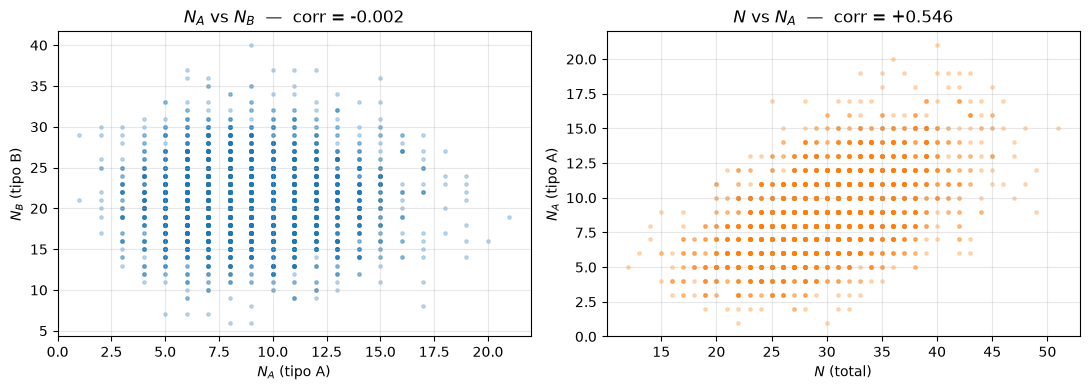

In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))

ejes[0].scatter(N_A[:3000], N_B[:3000], s=6, alpha=0.25)
ejes[0].set_title(f"$N_A$ vs $N_B$  —  corr = {np.corrcoef(N_A, N_B)[0,1]:+.3f}")
ejes[0].set_xlabel("$N_A$ (tipo A)"); ejes[0].set_ylabel("$N_B$ (tipo B)")

ejes[1].scatter(N_total[:3000], N_A[:3000], s=6, alpha=0.25, color="tab:orange")
ejes[1].set_title(f"$N$ vs $N_A$  —  corr = {np.corrcoef(N_total, N_A)[0,1]:+.3f}")
ejes[1].set_xlabel("$N$ (total)"); ejes[1].set_ylabel("$N_A$ (tipo A)")

for e in ejes: e.grid(alpha=0.3)
plt.tight_layout(); plt.show()

La nube de la izquierda es **redonda**, por lo que no hay ninguna tendencia. Mientras que la de la derecha es claramente inclinada.

**¿Por qué funciona así?** Porque el total $N$ no es un número fijo, es aleatorio. Cuando $N_A$ sale alto, eso es evidencia de que $N$ era alto, y las dos cosas se cancelan exactamente. Si el total estuviera fijo en $n$, entonces sí tendríamos $N_B = n - N_A$ y la correlación sería $-1$ perfecta.

**Para qué sirve en la práctica:** si el 65% de las llamadas de un call center son de soporte, puedes dimensionar el equipo de soporte tratándolo como **un sistema aparte** con tasa $0.65\lambda$, sin preocuparte por lo que hace ventas. Eso es lo que hace manejable el modelado de sistemas con varias clases de clientes.

## 6. El puente: tu generador de SimPy es un proceso de Poisson

Volvamos al comienzo. En las semanas 4 y 5 el generador de llegadas era este:

```python
def generador(env):
    while True:
        yield env.timeout(random.expovariate(lam))
        env.process(cliente(env, ...))
```

Eso es exactamente el algoritmo de la sección 1: esperar un tiempo $\text{Exp}(\lambda)$, registrar un evento, repetir. **Es un proceso de Poisson**, construido sin haberlo nombrado.

Compruébalo: dejamos correr el generador de SimPy y le aplicamos las mismas verificaciones de hoy.

In [10]:
random.seed(1)
lam_s, T_s = 3.0, 5_000.0

llegadas_simpy = []

def generador_llegadas(env):
    while True:
        yield env.timeout(random.expovariate(lam_s))
        llegadas_simpy.append(env.now)

env = simpy.Environment()
env.process(generador_llegadas(env))
env.run(until=T_s)

llegadas_simpy = np.array(llegadas_simpy)

# ¿Cuántos eventos hubo en cada unidad de tiempo? -> debería ser Poisson(lam)
N_por_unidad = np.histogram(llegadas_simpy, bins=np.arange(0, T_s+1, 1))[0]

print(f"Eventos generados por SimPy: {len(llegadas_simpy):,}\n")
print(f"E[N(1)]   = {N_por_unidad.mean():.4f}    teórica: {lam_s}")
print(f"Var[N(1)] = {N_por_unidad.var(ddof=1):.4f}    teórica: {lam_s}")
print(f"P(N(1)=0) = {np.mean(N_por_unidad == 0):.4f}    teórica: {stats.poisson.pmf(0, lam_s):.4f}")

p_simpy = stats.kstest(np.diff(llegadas_simpy), "expon", args=(0, 1/lam_s)).pvalue
print(f"\nKS de los interarribos vs Exp({lam_s}): p-valor = {p_simpy:.4f}")

Eventos generados por SimPy: 15,036

E[N(1)]   = 3.0072    teórica: 3.0
Var[N(1)] = 3.0930    teórica: 3.0
P(N(1)=0) = 0.0510    teórica: 0.0498

KS de los interarribos vs Exp(3.0): p-valor = 0.6573


> **Todo lo que sabes del proceso de Poisson aplica a tus modelos de SimPy.** Si un sistema recibe dos flujos de clientes con tasas $\lambda_1$ y $\lambda_2$, no necesitas dos generadores: por **superposición**, uno solo con $\lambda_1 + \lambda_2$ produce el mismo sistema. Y si dentro de un flujo el 30% de los clientes son de un tipo especial, por **división** puedes tratarlos como un proceso independiente de tasa $0.3\lambda$.

## 7. Ejercicio aplicado: centro de atención

Un centro de atención recibe llamadas según un proceso de Poisson con tasa $\lambda = 8$ llamadas por hora. Cada llamada se clasifica, de forma independiente, como:

- **Soporte** con probabilidad $p = 0.65$
- **Ventas** con probabilidad $1 - p = 0.35$

La celda de abajo **ya corre**, pero está incompleta. Reemplaza cada `# TODO`.

In [11]:
lam_cc = 8.0     # llamadas por hora
p_sop  = 0.65    # probabilidad de que una llamada sea de soporte
R_cc   = 50_000  # horas simuladas

rng_cc = np.random.default_rng(2026)

# ---------- Parte A: conteos en una hora ----------
# TODO A.1: simula R_cc horas de operación. N1 debe ser un array con el número
#           de llamadas de cada hora.  (pista: rng_cc.poisson)
N1 = np.zeros(R_cc, dtype=int)   # <-- placeholder, reemplázalo

# TODO A.2: estima E[N(1)], Var(N(1)) y P(N(1) >= 12), y compáralos con la teoría.
#           Para la teórica de la probabilidad usa stats.poisson.cdf


# ---------- Parte B: división por tipo ----------
# TODO B.1: para cada hora, ¿cuántas de esas llamadas fueron de soporte?
#           (pista: dado que hubo N llamadas, las de soporte son Binomial(N, p))
NS = np.zeros(R_cc, dtype=int)   # <-- placeholder
NV = np.zeros(R_cc, dtype=int)   # <-- placeholder

# TODO B.2: estima E[NS] y E[NV] y compáralos con p*lam y (1-p)*lam

# TODO B.3: estima P(NS = 0) y P(NV >= 5) y compáralos con la teoría

# TODO B.4: calcula la correlación entre NS y NV. ¿Qué esperabas y qué te dio?

### Parte C — La pregunta del jefe de ventas

El equipo de ventas son dos personas y quieren irse a almorzar **juntas, 30 minutos**, dejando el teléfono de ventas sin atender.

**Responde con un número:** ¿cuál es la probabilidad de que en esos 30 minutos **no entre ninguna llamada de ventas**?

Calcúlala de dos formas —**por simulación y con la fórmula teórica**— y que coincidan. Después responde en una frase: **¿le recomendarías al jefe de ventas que se vayan?**

> Piensa qué tasa y qué horizonte tienes que usar. No son los del enunciado original.

In [12]:
# TODO C: probabilidad de que no entre ninguna llamada de ventas en 30 minutos
#         (por simulación y por fórmula)

<details>
<summary><b>Solución</b> (ábrela solo después de intentarlo)</summary>

<br>

**Ni lo intentes ;)**

Aquí no hay solución, este ejercicio es lo último que haces antes del Laboratorio 1, así que es tu mejor oportunidad para descubrir qué **no** te quedó claro mientras todavía puedes pedir ayuda.

Todo lo que necesitas ya lo corriste hoy. La parte A es la sección 3, la parte B es la sección 5, y la parte C es la misma idea de la parte B pero cambiando la tasa y el horizonte.

Cuando tengas tus números, compáralos con tu compañero y luego los revisan con el asistente graduado. 

</details>

## Resumen del módulo

Cierra aquí el primer módulo del curso. Lo que hay que llevarse a al Laboratorio 1 es esto:

| Semana | Idea que se evalúa |
|---|---|
| 1 | Python y NumPy: vectorizar en vez de iterar cuando se puede |
| 2 | **Monte Carlo estima, no calcula.** El error viene del tamaño de muestra |
| 2 | **Transformada inversa:** $X = F^{-1}(U)$ convierte uniformes en cualquier distribución |
| 3 | **TLC:** los promedios se vuelven Normales, y eso permite poner **intervalos de confianza** a una estimación de simulación |
| 4 | **SimPy:** entorno, procesos, `yield`, `Resource`, `Container`. El reloj salta entre eventos |
| 5 | **Colas:** medir $W_q$ y $W$ sobre *clientes*, $L$ y $L_q$ sobre el *tiempo*. Ley de Little. Nunca concluir de una sola corrida |
| 6 | **Poisson:** el modelo de las llegadas, y sus propiedades de superposición y división |
